In [1]:
import pandas as pd
import numpy as np
from src.model_pipeline import ModelPipeline

In [2]:
# df_final = pd.read_parquet("data/feature_engineering/debit/v2/df_union_debit_final.parquet")
# df_final = pd.read_parquet("data/feature_engineering/debit/v2/df_union_debit_final_20250620.parquet")
df_final = pd.read_parquet("data/feature_engineering/debit/v2/df_union_debit_final_20250629.parquet")
df_final = df_final.set_index("Transaction Serial No", drop=True)

# Final Drop Columns

In [3]:
all_feats = [
    'CntUnique_CardNo_by_cardAcceptor_cat_L90D',
    'CntUnique_CardNo_by_cardAcceptor_cat_L14D',
    'CntUnique_CardNo_by_cardAcceptor_cat_L1D',
    'CntUnique_CardNo_by_cardAcceptor_cat_L7D',
    'Sum_Amt_L90D',
    'CntUnique_CardNo_by_cardAcceptor_cat_L30D',
    'Sum_Amt_to_cardAcceptor_cat_L90D',
    'CntUnique_CardNo_by_MCC_L14D',
    'TxnCount_to_cardAcceptor_cat_L30D',
    'Sum_Amt_L30D',
    'Sum_Amt_to_cardAcceptor_cat_L30D',
    'TotalTrxAmount15Mi',
    'Transaction Amount',
    'Sum_Amt_L14D',
    'CntUnique_CardNo_by_MCC_L7D',
    'TxnCount_to_cardAcceptor_cat_L14D',
    'TotalTrxAmount10Mi',
    'CntUnique_CardNo_by_MCC_L30D',
    'CntUnique_CardNo_by_MCC_L1D',
    'TotalTrxAmountL5min',
    'TxnCount_L90D',
    'TxnCount_L30D',
    'CntUnique_CardNo_by_MCC_L90D',
    'TxnCount_L14D',
    'Sum_Amt_to_cardAcceptor_cat_L14D',
    'CountTrxTrf',
    'TotalTrxAmountL1D',
    'TxnCount_L7D',
    'TxnCount_to_cardAcceptor_cat_L90D',
    'TxnCount_to_cardAcceptor_cat_L7D',
    'Balance',
    'Sum_Amt_to_cardAcceptor_cat_L7D',
    'TotalTrxAmountTrf2',
    'TotalTrxAmountTrf',
    'CustomerNationality_FE',
    'CntUnique_CardNo_by_cardAcceptor_country_L90D',
    'CntUnique_CardNo_by_cardAcceptor_country_L7D',
    'Avg_Amt_L90D',
    'CntUnique_CardNo_by_cardAcceptor_country_L14D',
    'Max_Amt_to_cardAcceptor_cat_L14D',
    'Max_Amt_to_cardAcceptor_cat_L30D',
    'CustomerAge',
    'Max_Amt_to_cardAcceptor_cat_L90D',
    'CntUnique_CardNo_by_cardAcceptor_country_L1D',
    'Max_Amt_L90D',
    'Avg_Amt_L30D',
    'CntUnique_CardNo_by_cardAcceptor_country_L30D',
    'CntUnique_CardNo_by_cardAcceptor_cat_L1H',
    'Avg_Amt_to_cardAcceptor_cat_L90D',
    'Max_Amt_L14D',
    'Max_Amt_to_cardAcceptor_cat_L7D',
    'Max_Amt_L30D',
    'AccountStatus_FE',
    'CntUnique_CardNo_by_MCC_L1H',
    'Avg_Amt_to_cardAcceptor_cat_L7D',
    'TxnCount_to_MCC_L90D',
    'CustomerSex_FE',
    'time_diff',
    'Max_Amt_L7D',
    'TxnCount_to_cardAcceptor_cat_L1D',
    'Sum_Amt_to_cardAcceptor_cat_L1D',
    'Max_Amt_L1D',
    'Avg_Amt_L1H',
    'Max_Amt_L1H',
    'TransactionType_FE',
    'Sum_Amt_to_MCC_L90D',
    'POSMode_FE',
    'HIghRiskCustomer_FE',
    'Avg_Amt_L1D',
    'Avg_Amt_to_cardAcceptor_cat_L1D',
    'TxnCount_L1D',
    'CardProduct_FE',
    'Max_Amt_to_cardAcceptor_cat_L1D',
    'CardStatus_FE',
    'Max_Amt_to_MCC_L90D',
    'Avg_Amt_to_MCC_L90D',
    'CntUnique_CardNo_by_cardAcceptor_country_L1H',
    'Max_Amt_L15M',
    'Sum_Amt_to_cardAcceptor_cat_L1H',
    'Max_Amt_to_CountryCode_L90D',
    'TxnCount_to_MCC_L30D',
    'Avg_Amt_to_MCC_L14D',
    'Avg_Amt_to_CountryCode_L1D',
    'TxnCount_to_MCC_L14D',
    'Max_Amt_to_MCC_L30D',
    'IsBillPayment',
    'Avg_Amt_L15M',
    'Avg_Amt_to_MCC_L7D',
    'Max_Amt_to_cardAcceptor_country_L14D',
    'Avg_Amt_to_cardAcceptor_cat_L1H',
    'Max_Amt_to_cardAcceptor_cat_L1H',
    'Avg_Amt_to_MCC_L30D',
    'Sum_Amt_to_cardAcceptor_cat_L15M',
    'Sum_Amt_to_MCC_cat_L30D',
    'Max_Amt_to_MCC_L14D',
    'Max_Amt_to_MCC_L7D',
    'Max_Amt_to_CountryCode_L14D',
    'Sum_Amt_to_MCC_L30D',
    'Max_Amt_to_cardAcceptor_country_L90D',
    'CntUnique_CardNo_by_cardAcceptor_cat_L15M',
    'PINEntryCapability_FE',
    'Sum_Amt_to_MCC_L14D',
    'Sum_Amt_to_MCC_L7D',
    'Avg_Amt_to_cardAcceptor_country_L30D',
    'TxnCount_to_MCC_cat_L90D',
    'CntUnique_CardNo_by_MCC_L15M',
    'TotalTrxAmountTopUp2',
    'TxnCount_to_MCC_catcode_L90D',
    'Max_Amt_to_CountryCode_L1D',
    'Avg_Amt_to_CountryCode_L90D',
    'Avg_Amt_to_cardAcceptor_country_L90D',
    'TotalTrxAmountVA1',
    'Avg_Amt_to_CountryCode_L30D',
    'Max_Amt_to_cardAcceptor_cat_L15M',
    'Country Code_FE',
    'VCardDataInputCapability_FE',
    'Avg_Amt_to_cardAcceptor_country_L1D',
    'Sum_Amt_to_CountryCode_L14D',
    'Sum_Amt_to_CountryCode_L90D',
    'Sum_Amt_to_cardAcceptor_country_L90D',
    'Sum_Amt_to_CountryCode_L30D',
    'TxnCount_to_MCC_cat_L30D',
    'Avg_Amt_to_cardAcceptor_cat_L15M',
    'Avg_Amt_to_cardAcceptor_country_L14D',
    'Cat Card Acceptor Name_FE',
    'TxnCount_to_MCC_catcode_L14D',
    'Avg_Amt_to_CountryCode_L14D',
    'AgeOfOpenAcctTxn',
    'Max_Amt_to_cardAcceptor_country_L30D',
    'Max_Amt_to_CountryCode_L7D',
    'TxnCount_to_cardAcceptor_country_L90D',
    'TxnCount_to_CountryCode_L90D',
    'TxnCount_to_MCC_L7D',
    'TotalTrxAmountTopUp1',
    'TxnCount_to_MCC_catcode_L7D',
    'Max_Amt_to_CountryCode_L30D',
    'IsDCashTrx_FE',
    'TxnCount_to_MCC_cat_L14D',
    'Max_Amt_to_cardAcceptor_country_L1D',
    'Avg_Amt_to_MCC_cat_L30D',
    'Avg_Amt_to_MCC_cat_L90D',
    'TxnCount_to_MCC_catcode_L30D',
    'Avg_Amt_to_MCC_cat_L7D',
    'TxnCount_to_cardAcceptor_country_L30D',
    'Sum_Amt_to_cardAcceptor_country_L1D',
    'IsTopUp',
    'CountTrxTrf2',
    'MCC Category_FE',
    'Sum_Amt_to_cardAcceptor_country_L30D',
    'TxnCount_to_CountryCode_L30D',
    'Sum_Amt_to_cardAcceptor_country_L7D',
    'AccessCode_FE',
    'Avg_Amt_to_CountryCode_L7D',
    'Max_Amt_to_cardAcceptor_country_L1H',
    'Sum_Amt_to_MCC_L1H',
    'TotalTrxAmountContactlessPerDay',
    'Sum_Amt_to_MCC_cat_L14D',
    'IsQRtrx_FE',
    'Avg_Amt_to_MCC_L1D',
    'TotalTrxAmountContactless',
    'TxnCount_to_cardAcceptor_country_L14D',
    'Sum_Amt_to_CountryCode_L7D',
    'Sum_Amt_to_cardAcceptor_country_L14D',
    'Avg_Amt_to_MCC_cat_L1D',
    'TxnCount_to_MCC_cat_L7D',
    'Sum_Amt_to_CountryCode_L1D',
    'Avg_Amt_to_cardAcceptor_country_L1H',
    'Avg_Amt_to_MCC_cat_L14D',
    'Avg_Amt_to_cardAcceptor_country_L7D',
    'Max_Amt_to_cardAcceptor_country_L7D',
    'Avg_Amt_to_CountryCode_L1H',
    'Max_Amt_to_MCC_L1D',
    'TxnCount_to_CountryCode_L14D',
    'TxnCount_to_CountryCode_L7D',
    'Max_Amt_to_CountryCode_L1H',
    'Sum_Amt_to_cardAcceptor_country_L15M',
    'TxnCount_to_cardAcceptor_country_L7D',
    'Sum_Amt_to_MCC_L1D',
    'Max_Amt_to_MCC_L15M',
    'Avg_Amt_to_MCC_L1H',
    'Sum_Amt_to_MCC_L15M',
    'Avg_Amt_to_cardAcceptor_country_L15M',
    'Max_Amt_to_MCC_L1H',
    'Avg_Amt_to_MCC_L15M',
    'Max_Amt_to_cardAcceptor_country_L15M',
    'Max_Amt_to_CountryCode_L15M',
    'Sum_Amt_to_MCC_cat_L15M',
    'TxnCount_to_cardAcceptor_country_L1H',
    'Currency_FE',
    'TxnCount_to_MCC_L15M',
    'TxnCount_to_MCC_L1D',
    'Sum_Amt_to_CountryCode_L1H',
    'TxnCount_to_CountryCode_L1D',
    'TxnCount_to_cardAcceptor_country_L1D',
    'TxnCount_to_cardAcceptor_country_L15M',
    'TxnCount_to_CountryCode_L1H',
    'Avg_Amt_to_MCC_cat_L1H',
    'Sum_Amt_to_CountryCode_L15M',
    'CntUnique_CardNo_by_cardAcceptor_country_L15M',
    'TxnCount_to_MCC_L1H',
    'TxnCount_to_CountryCode_L15M',
    'Sum_Amt_to_MCC_cat_L1H',
    'Avg_Amt_to_CountryCode_L15M',
    'Sum_Amt_to_cardAcceptor_country_L1H'
]

In [3]:
derived_cols = [
    'Avg_Amt_L15M',
    'Avg_Amt_L1D',
    'Avg_Amt_L1H',
    'Avg_Amt_L30D',
    'Avg_Amt_L90D',
    'Avg_Amt_to_CountryCode_L14D',
    'Avg_Amt_to_CountryCode_L15M',
    'Avg_Amt_to_CountryCode_L1D',
    'Avg_Amt_to_CountryCode_L1H',
    'Avg_Amt_to_CountryCode_L30D',
    'Avg_Amt_to_CountryCode_L7D',
    'Avg_Amt_to_CountryCode_L90D',
    'Avg_Amt_to_MCC_L14D',
    'Avg_Amt_to_MCC_L15M',
    'Avg_Amt_to_MCC_L1D',
    'Avg_Amt_to_MCC_L1H',
    'Avg_Amt_to_MCC_L30D',
    'Avg_Amt_to_MCC_L7D',
    'Avg_Amt_to_MCC_L90D',
    'CntUnique_CardNo_by_MCC_L14D',
    'CntUnique_CardNo_by_MCC_L15M',
    'CntUnique_CardNo_by_MCC_L1D',
    'CntUnique_CardNo_by_MCC_L1H',
    'CntUnique_CardNo_by_MCC_L30D',
    'CntUnique_CardNo_by_MCC_L7D',
    'CntUnique_CardNo_by_MCC_L90D',
    'Max_Amt_L14D',
    'Max_Amt_L15M',
    'Max_Amt_L1D',
    'Max_Amt_L1H',
    'Max_Amt_L30D',
    'Max_Amt_L7D',
    'Max_Amt_L90D',
    'Max_Amt_to_CountryCode_L14D',
    'Max_Amt_to_CountryCode_L15M',
    'Max_Amt_to_CountryCode_L1D',
    'Max_Amt_to_CountryCode_L1H',
    'Max_Amt_to_CountryCode_L30D',
    'Max_Amt_to_CountryCode_L7D',
    'Max_Amt_to_CountryCode_L90D',
    'Max_Amt_to_MCC_L14D',
    'Max_Amt_to_MCC_L15M',
    'Max_Amt_to_MCC_L1D',
    'Max_Amt_to_MCC_L1H',
    'Max_Amt_to_MCC_L30D',
    'Max_Amt_to_MCC_L7D',
    'Max_Amt_to_MCC_L90D',
    'Sum_Amt_L14D',
    'Sum_Amt_L30D',
    'Sum_Amt_L90D',
    'Sum_Amt_to_CountryCode_L14D',
    'Sum_Amt_to_CountryCode_L15M',
    'Sum_Amt_to_CountryCode_L1D',
    'Sum_Amt_to_CountryCode_L1H',
    'Sum_Amt_to_CountryCode_L30D',
    'Sum_Amt_to_CountryCode_L7D',
    'Sum_Amt_to_CountryCode_L90D',
    'Sum_Amt_to_MCC_L14D',
    'Sum_Amt_to_MCC_L15M',
    'Sum_Amt_to_MCC_L1D',
    'Sum_Amt_to_MCC_L1H',
    'Sum_Amt_to_MCC_L30D',
    'Sum_Amt_to_MCC_L7D',
    'Sum_Amt_to_MCC_L90D',
    'TxnCount_L15M',
    'TxnCount_L14D',
    'TxnCount_L1D',
    'TxnCount_L30D',
    'TxnCount_L7D',
    'TxnCount_L90D',
    'TxnCount_to_CountryCode_L14D',
    'TxnCount_to_CountryCode_L15M',
    'TxnCount_to_CountryCode_L1D',
    'TxnCount_to_CountryCode_L1H',
    'TxnCount_to_CountryCode_L30D',
    'TxnCount_to_CountryCode_L7D',
    'TxnCount_to_CountryCode_L90D',
    'TxnCount_to_MCC_L14D',
    'TxnCount_to_MCC_L15M',
    'TxnCount_to_MCC_L1D',
    'TxnCount_to_MCC_L1H',
    'TxnCount_to_MCC_L30D',
    'TxnCount_to_MCC_L7D',
    'TxnCount_to_MCC_L90D',
    'time_diff',
    'AvgTrnxHourL15min',
    'AvgTrnxHourL1h',
    'AvgTrnxHourL1d',
    'AvgTrnxHourL14d',
    'AvgTrnxHourL30d'
] + [# duration since first trnx
    col for col in df_final.columns if "DurationSinceFirstTrnx" in col
] + [# freq and monetary cols grouped by POSMode
    col for col in df_final.columns if "ToPOSMode" in col
]

In [5]:
non_derived_cols = [
    # 'AccessCode',
    'AccountStatus',
    'CardProduct',
    # 'CardStatus',
    # 'Cat Card Acceptor Name',
    'CountTrxTrf',
    'Country Code',
    'Currency',
    'CustomerAge',
    # 'CustomerNationality', high-cardinality
    'CustomerSex',
    'HIghRiskCustomer',
    # 'IsDCashTrx', low importance value
    # 'IsQRtrx', low importance value
    # 'MCC Category', low importance value
    # 'PINEntryCapability',
    'POSMode',
    'TotalTrxAmount10Mi',
    'TotalTrxAmount15Mi',
    'TotalTrxAmountL1D',
    'TotalTrxAmountL5min',
    'Transaction Amount',
    'TransactionType',
    # 'VCardDataInputCapability' low importance value
] + [# is top 10 high risk category
    col for col in df_final.columns if "IsTop10HighRisk" in col
]

In [7]:
selected_derived_cols = [
    col for col in derived_cols
    if any(substr in col for substr in ["L15M", "L30D","L15min","L30d"])
] + ['time_diff'] + [
    'DurationSinceFirstTrnxToCurrentMCC',
    'DurationSinceFirstTrnxToCurrentCountryCode'
]

In [8]:
selected_derived_cols

['Avg_Amt_L15M',
 'Avg_Amt_L30D',
 'Avg_Amt_to_CountryCode_L15M',
 'Avg_Amt_to_CountryCode_L30D',
 'Avg_Amt_to_MCC_L15M',
 'Avg_Amt_to_MCC_L30D',
 'CntUnique_CardNo_by_MCC_L15M',
 'CntUnique_CardNo_by_MCC_L30D',
 'Max_Amt_L15M',
 'Max_Amt_L30D',
 'Max_Amt_to_CountryCode_L15M',
 'Max_Amt_to_CountryCode_L30D',
 'Max_Amt_to_MCC_L15M',
 'Max_Amt_to_MCC_L30D',
 'Sum_Amt_L30D',
 'Sum_Amt_to_CountryCode_L15M',
 'Sum_Amt_to_CountryCode_L30D',
 'Sum_Amt_to_MCC_L15M',
 'Sum_Amt_to_MCC_L30D',
 'TxnCount_L15M',
 'TxnCount_L30D',
 'TxnCount_to_CountryCode_L15M',
 'TxnCount_to_CountryCode_L30D',
 'TxnCount_to_MCC_L15M',
 'TxnCount_to_MCC_L30D',
 'AvgTrnxHourL15min',
 'AvgTrnxHourL30d',
 'AvgDurationSinceFirstTrnxToCurrentMCCL15min',
 'AvgDurationSinceFirstTrnxToCurrentMCCL30D',
 'AvgDurationSinceFirstTrnxToCurrentCountryCodeL15min',
 'AvgDurationSinceFirstTrnxToCurrentCountryCodeL30D',
 'TxnCountToPOSModeL15min',
 'TxnCountToPOSModeL30D',
 'AvgAmtToPOSModeL15min',
 'AvgAmtToPOSModeL30D',
 'MaxAmtToP

In [9]:
final_feats = selected_derived_cols + non_derived_cols + ["Transaction Datetime", "Confirmed"]

In [10]:
len(selected_derived_cols), len(non_derived_cols), len(selected_derived_cols + non_derived_cols)

(42, 16, 58)

In [11]:
df_final = df_final[final_feats]

## Create Ratio Features

In [12]:
def create_ratio_features(
    df: pd.DataFrame,
    feature_list: list,
    replace_str_1: str = '_L15M',
    replace_str_2: str = '_L30D',
    default_value: float = -999
) -> pd.DataFrame:
    """
    Automatically creates ratio features of the form L30D, L15M
    for matching base features from the provided feature list
    """
    l15m_feats = {col.replace(replace_str_1, ''): col for col in feature_list if replace_str_1 in col}
    l30d_feats = {col.replace(replace_str_2, ''): col for col in feature_list if replace_str_2 in col}

    # find matching base feature names
    matching_bases = set(l15m_feats.keys()) & set(l30d_feats.keys())

    # create ratio columns
    for base in matching_bases:
        col_15m = l15m_feats[base]
        col_30d = l30d_feats[base]
        new_col = f'Ratio{base}L30DL15min'

        # calculate the ratio with save division
        ratio = df[col_30d] / df[col_15m]
        ratio = ratio.replace([np.inf, -np.inf], np.nan) # handle div by zero

        # fill 0/0 or NaNs or infinities with default value
        df[new_col] = ratio.fillna(default_value)

    return df

In [13]:
df_final = create_ratio_features(
    df_final,
    selected_derived_cols,
    '_L15M',
    '_L30D'
)

In [14]:
df_final = create_ratio_features(
    df_final,
    selected_derived_cols,
    'L15min',
    'L30D'
)

## Modify CardProduct Grouping

In [15]:
def standardize_to_string_int(val):
    if val == "__missing__":
        return "__missing__"
    try:
        numeric_val = float(val)
        if numeric_val == int(numeric_val):
            return str(int(numeric_val))
        else:
            return str(numeric_val)
    except (ValueError, TypeError):
        return str(val)

def get_card_product_group(val):
    if val == "__missing__":
        return "__missing__"

    s_val = str(val)
    
    if len(s_val) > 0 and s_val[0].isdigit():
        first_digit = int(s_val[0])
        if 1 <= first_digit <= 7:
            return f'card_product_{first_digit}'
        else:
            return 'card_product_other'

    else:
        return 'card_product_other'

In [16]:
df_final['CardProduct'] = df_final['CardProduct'].fillna('__missing__')
df_final['CardProduct'] = df_final['CardProduct'].apply(standardize_to_string_int)
df_final['CardProductGrouped'] = df_final['CardProduct'].apply(get_card_product_group)

In [17]:
df_final['CardProductGrouped'] = df_final['CardProductGrouped'].replace({'__missing__': np.nan})

## Modify CountryCode

In [18]:
is_whitespace_or_empty = (df_final['Country Code'].str.strip() == '')

df_final['Country Code'] = df_final['Country Code'].fillna('__missing__')
df_final['Country Code'] = np.where(
    is_whitespace_or_empty,
    '__missing__',
    df_final['Country Code']
)

In [19]:
specific_country_code = ['IDN','MYS','AUS','SGP']

df_final['CountryCodeGroup'] = np.where(
    df_final['Country Code'].isin(specific_country_code),
    df_final['Country Code'],
    'others'
)

In [20]:
df_final.drop(['Country Code','CardProduct'], axis=1, inplace=True)

In [21]:
# ratio 1
df_final['RatioTrxAmountL1DL5min'] = df_final['TotalTrxAmountL1D']/df_final['TotalTrxAmountL5min']
df_final['RatioTrxAmountL1DL5min'] = df_final['RatioTrxAmountL1DL5min'].replace([np.inf, -np.inf], np.nan)
df_final['RatioTrxAmountL1DL5min'] = df_final['RatioTrxAmountL1DL5min'].fillna(-999)

In [22]:
# ratio 2
df_final['RatioTrxAmountL1DL15min'] = df_final['TotalTrxAmountL1D']/df_final['TotalTrxAmount15Mi']
df_final['RatioTrxAmountL1DL15min'] = df_final['RatioTrxAmountL1DL15min'].replace([np.inf, -np.inf], np.nan)
df_final['RatioTrxAmountL1DL15min'] = df_final['RatioTrxAmountL1DL15min'].fillna(-999)

In [23]:
# ratio 3
df_final['RatioTrxAmountL1DL10min'] = df_final['TotalTrxAmountL1D']/df_final['TotalTrxAmount10Mi']
df_final['RatioTrxAmountL1DL10min'] = df_final['RatioTrxAmountL1DL10min'].replace([np.inf, -np.inf], np.nan)
df_final['RatioTrxAmountL1DL10min'] = df_final['RatioTrxAmountL1DL10min'].fillna(-999)

In [47]:
df_final.to_parquet("data/ready_to_train/DEBIT_df_final_81_feats_20250629.parquet")

# Rename df_final Columns

In [26]:
renamed_column_map = {
    'Avg_Amt_L15M': 'AvgAmtL15min',
    'Avg_Amt_L30D': 'AvgAmtL30D',
    'Avg_Amt_to_CountryCode_L15M': 'AvgAmtToCountryCodeL15min',
    'Avg_Amt_to_CountryCode_L30D': 'AvgAmtToCountryCodeL30D',
    'Avg_Amt_to_MCC_L15M': 'AvgAmtToMCCL15min',
    'Avg_Amt_to_MCC_L30D': 'AvgAmtToMCCL30D',
    'CntUnique_CardNo_by_MCC_L15M': 'CntUniqueCardNoByMCCL15min',
    'CntUnique_CardNo_by_MCC_L30D': 'CntUniqueCardNoByMCCL30D',
    'HIghRiskCustomer': 'HighRiskCustomer',
    'Max_Amt_L15M': 'MaxAmtL15min',
    'Max_Amt_L30D': 'MaxAmtL30D',
    'Max_Amt_to_CountryCode_L15M': 'MaxAmtToCountryCodeL15min',
    'Max_Amt_to_CountryCode_L30D': 'MaxAmtToCountryCodeL30D',
    'Max_Amt_to_MCC_L15M': 'MaxAmtToMCCL15min',
    'Max_Amt_to_MCC_L30D': 'MaxAmtToMCCL30D',
    'Sum_Amt_L30D': 'SumAmtL30D',
    'Sum_Amt_to_CountryCode_L15M': 'SumAmtToCountryCodeL15min',
    'Sum_Amt_to_CountryCode_L30D': 'SumAmtToCountryCodeL30D',
    'Sum_Amt_to_MCC_L15M': 'SumAmtToMCCL15min',
    'Sum_Amt_to_MCC_L30D': 'SumAmtToMCCL30D',
    'Transaction Amount': 'TransactionAmount',
    'Transaction Datetime': 'TransactionDatetime',
    'TxnCount_L15M': 'TxnCountL15min',
    'TxnCount_L30D': 'TxnCountL30D',
    'TxnCount_to_CountryCode_L15M': 'TxnCountToCountryCodeL15min',
    'TxnCount_to_CountryCode_L30D': 'TxnCountToCountryCodeL30D',
    'TxnCount_to_MCC_L15M': 'TxnCountToMCCL15min',
    'TxnCount_to_MCC_L30D': 'TxnCountToMCCL30D',
    'ratio_avg_amt_L30D_L15M': 'RatioAvgAmtL30DL15min',
    'ratio_avg_amt_to_countrycode_L30D_L15M': 'RatioAvgAmtToCountryCodeL30DL15min',
    'ratio_avg_amt_to_mcc_L30D_L15M': 'RatioAvgAmtToMCCL30DL15min',
    'ratio_cntunique_cardno_by_mcc_L30D_L15M': 'RatioCntUniqueCardNoByMCCL30DL15min',
    'ratio_max_amt_L30D_L15M': 'RatioMaxAmtL30DL15min',
    'ratio_max_amt_to_mcc_L30D_L15M': 'RatioMaxAmtToMCCL30DL15min',
    'ratio_sum_amt_to_mcc_L30D_L15M': 'RatioSumAmtToMCCL30DL15min',
    'ratio_max_amt_to_countrycode_L30D_L15M': 'RatioMaxAmtToCountryCodeL30DL15min',
    'ratio_sum_amt_to_countrycode_L30D_L15M': 'RatioSumAmtToCountryCodeL30DL15min',
    'ratio_txncount_L30D_L15M': 'RatioTxnCountL30DL15min',
    'ratio_txncount_to_countrycode_L30D_L15M': 'RatioTxnCountToCountryCodeL30DL15min',
    'ratio_txncount_to_mcc_L30D_L15M': 'RatioTxnCountToMCCL30DL15min',
    'time_diff': 'TxnTimeDiff'
}

In [27]:
df_final.rename(columns=renamed_column_map, inplace=True)

# Split and Prepare DF

In [24]:
split_date = "2025-05-01"

In [26]:
# setup pipeline
pipeline = ModelPipeline(
    model_type="random_forest",
    random_state=42
)

df_splits = pipeline.split_data_by_date(
    df=df_final,
    date_column="Transaction Datetime",
    split_date=split_date
)

Initializing ModelPipeline with model type: random_forest
Retrieving model instance for type: random_forest
Splitting data by date (pre-preprocessing)...
Train samples: 647760, Test samples: 66974
Data splitting complete.


In [27]:
# prepare TRAIN data
target_col = "Confirmed"
X, y = pipeline.prepare_data(
    df=df_splits["df_train"],
    target_column=target_col,
    exclude_columns=["Transaction Datetime"],
    is_apply_one_hot=True,
    is_apply_log=False,
    is_impute_median=False,
    is_training=True
)

Preparing data (is_training=True)...
Starting core numeric and boolean preprocessing...
Core numeric and boolean preprocessing complete.
Fitting CategoryManager...
  Fitted categories for column 'AccountStatus': ['1', '2', '3', '6', '7', '8', '__missing__']
  Fitted categories for column 'Currency': ['IDR', '__missing__']
  Fitted categories for column 'CustomerSex': ['F', 'M', '__missing__']
  Fitted categories for column 'HIghRiskCustomer': ['0', 'N', '__missing__']
  Fitted categories for column 'POSMode': ['0', '1', '2', '5', '7', '9', '__missing__']
  Fitted categories for column 'TransactionType': ['0', '1', '23', '31', '4', '40', '50', '51', 'BI', 'CA', 'DC', 'FT', 'IN', 'PA', '__missing__']
  Fitted categories for column 'CardProductGrouped': ['CARD_PRODUCT_1', 'CARD_PRODUCT_2', 'CARD_PRODUCT_3', 'CARD_PRODUCT_4', 'CARD_PRODUCT_5', 'CARD_PRODUCT_6', 'CARD_PRODUCT_7', 'CARD_PRODUCT_OTHER', '__missing__']
  Fitted categories for column 'CountryCodeGroup': ['AUS', 'IDN', 'MYS', 'O

In [28]:
numerical_cols = [col for col in df_splits['df_train'].columns if col not in ['AccountStatus', 'Currency', 'CustomerSex', 'HIghRiskCustomer',
       'POSMode', 'TransactionType', 'CardProductGrouped', 'CountryCodeGroup', 'Confirmed']]

In [29]:
len(df_splits['df_train'].columns)

81

In [30]:
# split data
X_train, X_test, y_train, y_test = pipeline.split_data(X, y, test_size=0.3)

Splitting data into train and test sets...
Data splitting complete.


In [31]:
len(X.columns)

115

# Over-Sampling

In [32]:
from src.imbalance_learn import ImbalancedSampler

In [33]:
# OverSampling
ros_sampler = ImbalancedSampler(
    algorithm='RandomOverSampler',
    sampler_type='upsample',
    target_ratio=0.2, # 7%
    random_state=1234
)

X_train_ros, y_train_ros = ros_sampler.fit_resample(X_train, y_train)

Original dataset shape: Counter({0.0: 453118, 1.0: 314})
Resampled dataset shape using RandomOverSampler: Counter({0.0: 453118, 1.0: 90623})


# Model Fit

In [34]:
# build and trai0_n
pipeline.build_pipeline()
pipeline.train(X_train_ros, y_train_ros, show_training_log=False)

Building pipeline...
Pipeline built.
Training model...
Model training complete.


In [35]:
base_rf_ros = pipeline.get_model()

Returning trained model...


In [36]:
import pickle

filepath = "model/debit/base_rf_ros_115_feats_20250629.pkl"
with open(filepath, "wb") as f:
    pickle.dump(base_rf_ros, f)

In [37]:
# Evaluate
test_results = pipeline.evaluate(X_test, y_test)

Evaluating model...
Accuracy: 0.9807
AUC: 0.9678
PR AUC: 0.1133
Precision: 0.0235
Recall: 0.6593

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.98      0.99    194193
         1.0       0.02      0.66      0.05       135

    accuracy                           0.98    194328
   macro avg       0.51      0.82      0.52    194328
weighted avg       1.00      0.98      0.99    194328



### SMOTE Train

In [51]:
# SMOTE
# OverSampling
smote_sampler = ImbalancedSampler(
    algorithm='SMOTE',
    sampler_type='upsample',
    target_ratio=0.2, # 7%
    random_state=1234
)

X_train_smote, y_train_smote = smote_sampler.fit_resample(X_train, y_train)

pipeline.train(X_train_smote, y_train_smote, show_training_log=False)

Original dataset shape: Counter({0.0: 453118, 1.0: 314})
Resampled dataset shape using SMOTE: Counter({0.0: 453118, 1.0: 90623})
Training model...
Model training complete.


In [52]:
# Evaluate
smote_test_results = pipeline.evaluate(X_test, y_test)

Evaluating model...
Accuracy: 0.9867
AUC: 0.9671
PR AUC: 0.1152
Precision: 0.0307
Recall: 0.5926

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.99      0.99    194193
         1.0       0.03      0.59      0.06       135

    accuracy                           0.99    194328
   macro avg       0.52      0.79      0.53    194328
weighted avg       1.00      0.99      0.99    194328



In [53]:
base_rf_smote = pipeline.get_model()

Returning trained model...


# Eval Model

In [38]:
from src.utils import plot_confusion_matrix

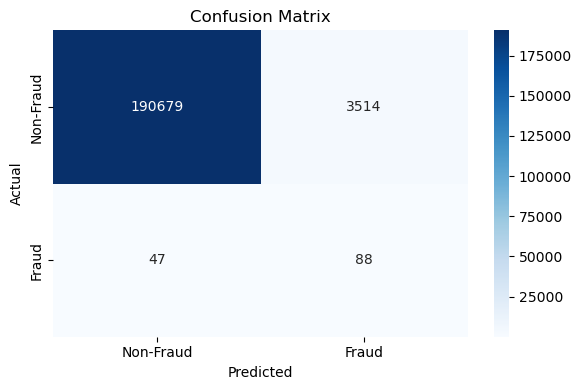

Recall/True Positive Rate: The model got 65.19% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 2.44% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 1.81% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [39]:
y_prob = base_rf_ros.predict_proba(X_test)[:, 1]
plot_confusion_matrix(y_test, y_prob, 0.5)

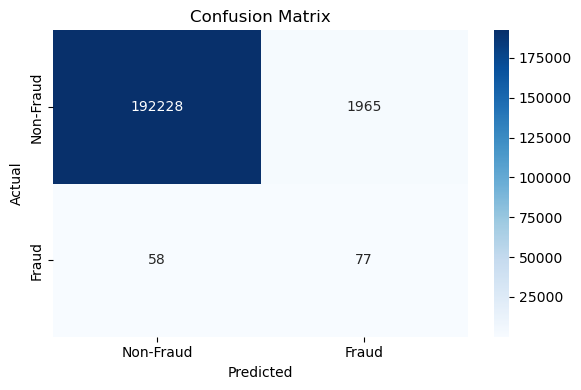

Recall/True Positive Rate: The model got 57.04% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 3.77% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 1.01% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [44]:
y_prob = base_rf_smote.predict_proba(X_test)[:, 1]
plot_confusion_matrix(y_test, y_prob, 0.5)

# Back-Testing with OOS Data

In [39]:
df_debit_mix = pd.read_parquet("data/base/df_debit_clean_v2.parquet")
trx_id_list = list(df_debit_mix[df_debit_mix.Confirmed.isin([0,1])]['Transaction Serial No'])
df_oos_new = df_splits["df_test"][df_splits["df_test"].index.isin(trx_id_list)]

In [40]:
X_oos, y_oos = pipeline.prepare_data(
    df=df_splits["df_test"],
    # df=df_oos_new,
    target_column=target_col,
    exclude_columns=["Transaction Datetime"],
    is_apply_one_hot=True,
    is_apply_log=False,
    is_impute_median=False,
    is_training=False
)

Preparing data (is_training=False)...
Starting core numeric and boolean preprocessing...
Core numeric and boolean preprocessing complete.
Transforming data using CategoryManager...
CategoryManager transformation complete.
Applying One-Hot Encoders for column: Index(['AccountStatus', 'Currency', 'CustomerSex', 'HIghRiskCustomer',
       'POSMode', 'TransactionType', 'CardProductGrouped', 'CountryCodeGroup'],
      dtype='object')...
Identified numerical columns for imputation: ['Avg_Amt_L15M', 'Avg_Amt_L30D', 'Avg_Amt_to_CountryCode_L15M', 'Avg_Amt_to_CountryCode_L30D', 'Avg_Amt_to_MCC_L15M', 'Avg_Amt_to_MCC_L30D', 'CntUnique_CardNo_by_MCC_L15M', 'CntUnique_CardNo_by_MCC_L30D', 'Max_Amt_L15M', 'Max_Amt_L30D', 'Max_Amt_to_CountryCode_L15M', 'Max_Amt_to_CountryCode_L30D', 'Max_Amt_to_MCC_L15M', 'Max_Amt_to_MCC_L30D', 'Sum_Amt_L30D', 'Sum_Amt_to_CountryCode_L15M', 'Sum_Amt_to_CountryCode_L30D', 'Sum_Amt_to_MCC_L15M', 'Sum_Amt_to_MCC_L30D', 'TxnCount_L15M', 'TxnCount_L30D', 'TxnCount_to_Cou

In [41]:
# Evaluate ALL trx
oos_results = pipeline.evaluate(X_oos, y_oos)

Evaluating model...
Accuracy: 0.9839
AUC: 0.9776
PR AUC: 0.0866
Precision: 0.0281
Recall: 0.7949

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.98      0.99     66935
         1.0       0.03      0.79      0.05        39

    accuracy                           0.98     66974
   macro avg       0.51      0.89      0.52     66974
weighted avg       1.00      0.98      0.99     66974



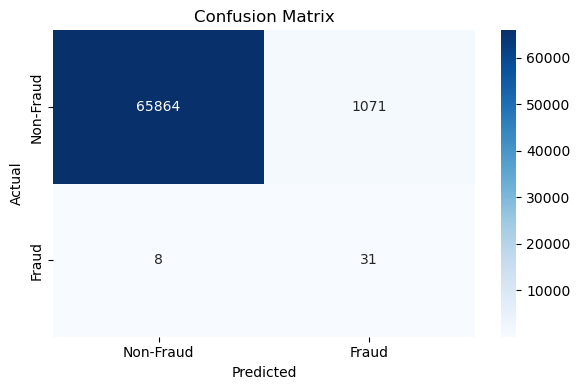

Recall/True Positive Rate: The model got 79.49% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 2.81% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 1.6% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [42]:
y_oos_prob = base_rf_ros.predict_proba(X_oos)[:, 1]
plot_confusion_matrix(y_oos, y_oos_prob, 0.5)

### SMOTE Eval

In [54]:
# Evaluate ALL trx
smote_oos_results = pipeline.evaluate(X_oos, y_oos)

Evaluating model...
Accuracy: 0.9891
AUC: 0.9797
PR AUC: 0.0901
Precision: 0.0374
Recall: 0.7179

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.99      0.99     66935
         1.0       0.04      0.72      0.07        39

    accuracy                           0.99     66974
   macro avg       0.52      0.85      0.53     66974
weighted avg       1.00      0.99      0.99     66974



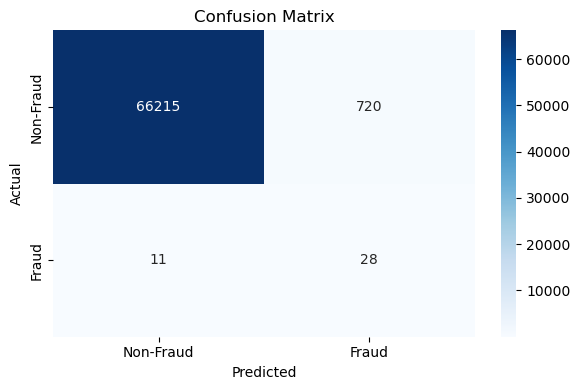

Recall/True Positive Rate: The model got 71.79% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 3.74% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 1.08% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [55]:
y_oos_prob = base_rf_smote.predict_proba(X_oos)[:, 1]
plot_confusion_matrix(y_oos, y_oos_prob, 0.5)

# Feature Importance

In [44]:
# Feature importance
importance_df = pipeline.get_feature_importance(X_train_ros, y_train_ros)

Getting feature importances...
  Using native feature importances.


In [45]:
importance_df['importance'] = np.round(importance_df['importance'], 6)
importance_numeric_cols_df = importance_df[importance_df['feature'].isin(numerical_cols)]
importance_numeric_cols_df.to_csv("data/result/importance/debit_base_rf_117_feats_importance_20250629.csv", index=False)

In [50]:
importance_numeric_cols_df.head(25).feature.tolist()

['Sum_Amt_L30D',
 'TxnCount_L30D',
 'CountTrxTrf',
 'TotalTrxAmount10Mi',
 'TotalTrxAmountL5min',
 'TotalTrxAmount15Mi',
 'CntUnique_CardNo_by_MCC_L30D',
 'TotalTrxAmountL1D',
 'Transaction Amount',
 'CustomerAge',
 'RatioTrxAmountL1DL15min',
 'RatioTrxAmountL1DL10min',
 'RatioTrxAmountL1DL5min',
 'Max_Amt_L30D',
 'Avg_Amt_L30D',
 'RatioCntUnique_CardNo_by_MCCL30DL15min',
 'RatioTxnCountL30DL15min',
 'AvgTrnxHourL30d',
 'time_diff',
 'DurationSinceFirstTrnxToCurrentMCC',
 'AvgDurationSinceFirstTrnxToCurrentMCCL30D',
 'AvgTrnxHourL15min',
 'CntUnique_CardNo_by_MCC_L15M',
 'Avg_Amt_to_MCC_L30D',
 'Max_Amt_to_MCC_L30D']

In [60]:
pd.set_option("display.max_rows", None)
importance_numeric_cols_df

,feature,importance
14,Sum_Amt_L30D,0.090715
20,TxnCount_L30D,0.088688
42,CountTrxTrf,0.074206
44,TotalTrxAmount10Mi,0.050683
47,TotalTrxAmountL5min,0.047184
45,TotalTrxAmount15Mi,0.045741
7,CntUnique_CardNo_by_MCC_L30D,0.043319
46,TotalTrxAmountL1D,0.041423
48,Transaction Amount,0.038000
43,CustomerAge,0.035766


In [61]:
len(importance_numeric_cols_df)

71

# Eval ALERT Transactions Only

In [ ]:
# Evaluate ALERT trx only
X_oos_new, y_oos_new = pipeline.prepare_data(
    # df=df_splits["df_test"],
    df=df_oos_new,
    target_column=target_col,
    exclude_columns=["Transaction Datetime"],
    is_training=False # set to False for back-testing/predicting OOS data
)

In [ ]:
# Evaluate ALERT trx only
oos_results = pipeline.evaluate(X_oos_new, y_oos_new)

In [ ]:
y_oos_new_prob = pipeline.pipeline.predict_proba(X_oos_new)[:, 1]
plot_confusion_matrix(y_oos_new, y_oos_new_prob, 0.5)